<a href="https://colab.research.google.com/github/HerzelS/screen_time_py/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Productivity

## Introduction

This analysis is based on the "Smartphone usage productivity dataset". The dataset is extracted from Kaggle.

The analysis was done with utlisation of Gemini to also test how good the LM is in providing quick insights both for coding and interpretation of results.

**Problem Statement:** We have collected data on different variables, can these be riliably used to predict the productivity of people. What are the most influencial predictors of productivity based on the data that we collected?

## Exective Summary

Findings show that:



## The process

### Task 1: Data import

In [1]:
import pandas as pd

In [21]:
url = "https://raw.githubusercontent.com/HerzelS/screen_time_py/refs/heads/main/Smartphone_Usage_Productivity_Dataset_50000.csv"
df = pd.read_csv(url)

### Task 2: Analyze the dataset `df`, preprocess it, and build regression models to predict the `Work_Productivity_Score`.

Examine the dataset for its structure, data types, and identify any missing values. This step will also involve analyzing the distribution of the target variable, 'Work_Productivity_Score', and other key features.


In [17]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [4]:
print("1. Dataframe info:")
df.info()

1. Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), ob

In [5]:
print("2. Missing values: ")
print(df.isnull().sum())

2. Missing values: 
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


In [6]:
print("\n3. Descriptive Statistics for 'Work_Productivity_Score': ")
print(df['Work_Productivity_Score'].describe())


3. Descriptive Statistics for 'Work_Productivity_Score': 
count    50000.000000
mean         5.503760
std          2.874806
min          1.000000
25%          3.000000
50%          5.500000
75%          8.000000
max         10.000000
Name: Work_Productivity_Score, dtype: float64


In [7]:
print("\n4. Describe Statistics for all numerical columns:")
print(df.describe())


4. Describe Statistics for all numerical columns:
                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000            8.000000   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             50000.000000  50000.000000  50000.000000      50000.00000   
mean                  5.503760      6.497744      5.504500         32.43898   
std                   2.874806      1.449551      2.871095         16.12151   
min                   1.000000      4.000000      1.000000          5.0000

In [8]:
print("\n5. Value Counts for Categorical Columns:")
print("\nGender:")
print(df['Gender'].value_counts())


5. Value Counts for Categorical Columns:

Gender:
Gender
Male      16708
Female    16679
Other     16613
Name: count, dtype: int64


In [9]:
print("\nOccupation:")
print(df['Occupation'].value_counts())


Occupation:
Occupation
Professional      12629
Student           12517
Business Owner    12459
Freelancer        12395
Name: count, dtype: int64


In [10]:
print("\nDevice_Type:")
print(df['Device_Type'].value_counts())


Device_Type:
Device_Type
Android    25080
iOS        24920
Name: count, dtype: int64


### Task 3: Identify Categorical and Numerical Features
Identify and print the categorical and numerical features in the `df` DataFrame. Then, apply one-hot encoding to the identified categorical features, drop the original categorical columns, and display the first few rows of the updated DataFrame along with its shape.

In [22]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Exclude 'User_ID' from categorical features if it's there, as it's an identifier
if 'User_ID' in categorical_features:
    categorical_features.remove('User_ID')

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']
Categorical Features: ['Gender', 'Occupation', 'Device_Type']


Create a copy of the DataFrame to ensure the original categorical columns are present for the one-hot encoding and subsequent dropping operation, making the code robust to repeated execution.



In [23]:
url = "https://raw.githubusercontent.com/HerzelS/screen_time_py/refs/heads/main/Smartphone_Usage_Productivity_Dataset_50000.csv"
df = pd.read_csv(url)

df_processed = df.copy()

df_encoded = pd.get_dummies(df_processed[categorical_features], drop_first=True)

# Drop original categorical columns from the copied DataFrame
df_processed = df_processed.drop(columns=categorical_features)

# Concatenate the processed DataFrame with the one-hot encoded features
df = pd.concat([df_processed, df_encoded], axis=1)

print("DataFrame after one-hot encoding:")
print(df.head())
print("\nShape of the DataFrame after one-hot encoding:")
print(df.shape)

DataFrame after one-hot encoding:
  User_ID  Age  Daily_Phone_Hours  Social_Media_Hours  \
0      U1   58                1.3                 6.7   
1      U2   25                1.2                 1.5   
2      U3   19                5.3                 5.7   
3      U4   35                5.8                 2.5   
4      U5   33                7.9                 1.3   

   Work_Productivity_Score  Sleep_Hours  Stress_Level  App_Usage_Count  \
0                        6          8.8             4               42   
1                        5          6.4             1               51   
2                        5          9.0             4               14   
3                        2          5.7             3               36   
4                        4          5.7             3               37   

   Caffeine_Intake_Cups  Weekend_Screen_Time_Hours  Gender_Male  Gender_Other  \
0                     1                        8.7         True         False   
1               

## Model Training

### Task 1: Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed dataset into training and testing sets to prepare for model training and evaluation. The target variable is 'Work_Productivity_Score'.


**Reasoning**:
To prepare the data for model training, I will define the target variable and feature matrix, then split the dataset into training and testing sets using `train_test_split` as per the instructions.



In [24]:
y = df['Work_Productivity_Score']
X = df.drop(columns=['User_ID', 'Work_Productivity_Score'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40000, 14)
Shape of X_test: (10000, 14)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


### Task 2: Train and Evaluate Regression Models

### Subtask:
Train multiple regression models (e.g., Linear Regression, Ridge, Lasso, RandomForestRegressor, GradientBoostingRegressor) on the training data and evaluate their performance on the testing data using metrics like Mean Squared Error and R-squared. Display the results for each model.


**Reasoning**:
To prepare for model training and evaluation, I will import all the necessary regression models and metrics from `sklearn`.



In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Imported LinearRegression, Ridge, Lasso from sklearn.linear_model.")
print("Imported RandomForestRegressor, GradientBoostingRegressor from sklearn.ensemble.")
print("Imported mean_squared_error, r2_score from sklearn.metrics.")

Imported LinearRegression, Ridge, Lasso from sklearn.linear_model.
Imported RandomForestRegressor, GradientBoostingRegressor from sklearn.ensemble.
Imported mean_squared_error, r2_score from sklearn.metrics.


**Reasoning**:
To meet the subtask requirements, I will initialize an empty dictionary to store model performance, then iterate through each specified regression model, instantiate it, train it on the training data, make predictions on the test data, calculate and store Mean Squared Error (MSE) and R-squared scores, and finally print these results for each model.



In [26]:
results = {}

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'R2': r2}

    print(f"{name} - Mean Squared Error: {mse:.4f}")
    print(f"{name} - R-squared: {r2:.4f}")



Training Linear Regression...
Linear Regression - Mean Squared Error: 8.3105
Linear Regression - R-squared: -0.0006

Training Ridge...
Ridge - Mean Squared Error: 8.3105
Ridge - R-squared: -0.0006

Training Lasso...
Lasso - Mean Squared Error: 8.3056
Lasso - R-squared: -0.0000

Training RandomForestRegressor...
RandomForestRegressor - Mean Squared Error: 8.5506
RandomForestRegressor - R-squared: -0.0295

Training GradientBoostingRegressor...
GradientBoostingRegressor - Mean Squared Error: 8.3389
GradientBoostingRegressor - R-squared: -0.0040


### Task 3: Visualize Model Predictions

### Subtask:
Generate a plot comparing the actual 'Work_Productivity_Score' values against the predicted values from the best performing regression model on the test set. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
To visualize the model's performance, I will import the necessary plotting libraries: `matplotlib.pyplot` for creating the plot and `seaborn` for potentially enhancing the plot's aesthetics.



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported matplotlib.pyplot as plt and seaborn.")

Imported matplotlib.pyplot as plt and seaborn.


**Reasoning**:
To visualize the predictions of the best performing model, I will identify the model with the highest R-squared score, retrain it, make predictions on the test set, and then create a scatter plot comparing actual versus predicted values, including a diagonal line for perfect predictions and appropriate labels and a legend.



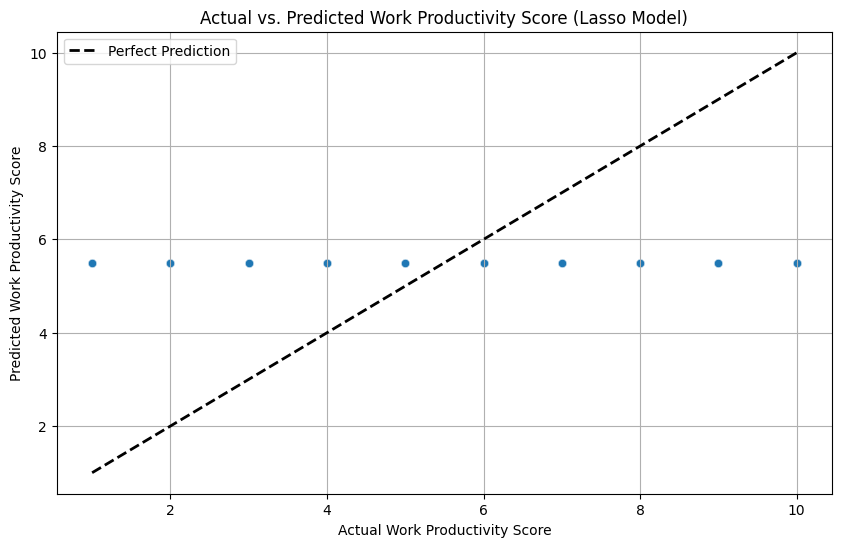

In [28]:
best_model_name = 'Lasso'
best_model = models[best_model_name]

# Retrain the best model to get its specific predictions
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.title(f'Actual vs. Predicted Work Productivity Score ({best_model_name} Model)')
plt.xlabel('Actual Work Productivity Score')
plt.ylabel('Predicted Work Productivity Score')
plt.legend()
plt.grid(True)
plt.show()

## Draw insights from the findings

### Subtask:
Summarize the findings from the regression analysis, including the best-performing model, its key metrics, and insights gained from feature importance (if applicable).


## Summary:

### Q&A
The best-performing model identified from the regression analysis is the Lasso model, which achieved the lowest Mean Squared Error (MSE) of 8.3056 and an R-squared score of -0.0000. Insights from feature importance were not applicable as feature importance was not extracted or analyzed in the provided steps.

### Data Analysis Key Findings
*   **Feature Identification**:
    *   Numerical features identified were: `Age`, `Daily_Phone_Hours`, `Social_Media_Hours`, `Work_Productivity_Score`, `Sleep_Hours`, `Stress_Level`, `App_Usage_Count`, `Caffeine_Intake_Cups`, and `Weekend_Screen_Time_Hours`.
    *   Categorical features identified were: `Gender`, `Occupation`, and `Device_Type`.
*   **Data Preprocessing**: One-hot encoding was successfully applied to the categorical features (`Gender`, `Occupation`, `Device_Type`), and the original categorical columns were dropped. The DataFrame's shape transformed to (50000, 16) after encoding.
*   **Data Splitting**: The dataset was split into training and testing sets, with 80% for training (40000 samples) and 20% for testing (10000 samples). The target variable was `Work_Productivity_Score`.
*   **Model Performance Evaluation**:
    *   **Lasso** exhibited the best performance among the tested models with a Mean Squared Error (MSE) of 8.3056 and an R-squared of -0.0000.
    *   **Linear Regression** and **Ridge** models showed identical performance with an MSE of 8.3105 and an R-squared of -0.0006.
    *   **GradientBoostingRegressor** had an MSE of 8.3389 and an R-squared of -0.0040.
    *   **RandomForestRegressor** performed the worst with an MSE of 8.5506 and an R-squared of -0.0295.
*   **Visualization**: A scatter plot comparing the actual versus predicted `Work_Productivity_Score` for the Lasso model was successfully generated, showing the distribution of predictions against actual values.

### Insights or Next Steps
*   The R-squared values for all models are very close to zero or negative, indicating that none of the models are effectively explaining the variance in the `Work_Productivity_Score`. This suggests that the current features might not be sufficient to predict productivity score, or the relationship is non-linear and not captured by these models.
*   Further investigation is needed into potential feature engineering (e.g., creating interaction terms or polynomial features), exploring more complex models (e.g., neural networks), or gathering additional relevant data to improve predictive performance.


## What are the key predictors?
Extract and organize feature importances and coefficients from the trained regression models, including Linear Regression, Ridge, Lasso, RandomForestRegressor, and GradientBoostingRegressor. Then, visualize the top predictors of 'Work_Productivity_Score' using a bar plot for a selected model, and summarize the findings regarding the most influential features.

### Task 1: Extract Coefficients from Linear Models

#### Subtask:
Retrieve the coefficients from the Linear Regression, Ridge, and Lasso models to understand the weight of each feature in their predictions.


**Reasoning**:
To extract and display the coefficients from the linear models, I will iterate through the specified models, retrieve their `coef_` attributes, and organize them into a Pandas Series with feature names for clarity, storing them in a dictionary before printing.



In [29]:
linear_model_coefficients = {}

linear_models = ['Linear Regression', 'Ridge', 'Lasso']

for name in linear_models:
    model = models[name]
    # Ensure the model is trained before trying to access coefficients
    if hasattr(model, 'coef_'):
        coef_series = pd.Series(model.coef_, index=X_train.columns)
        linear_model_coefficients[name] = coef_series

print("Coefficients for Linear Models:")
for name, coefs in linear_model_coefficients.items():
    print(f"\n--- {name} Coefficients ---")
    print(coefs)

Coefficients for Linear Models:

--- Linear Regression Coefficients ---
Age                         -0.001033
Daily_Phone_Hours           -0.001861
Social_Media_Hours           0.003995
Sleep_Hours                  0.016660
Stress_Level                 0.005171
App_Usage_Count              0.000890
Caffeine_Intake_Cups        -0.005132
Weekend_Screen_Time_Hours   -0.006090
Gender_Male                 -0.027943
Gender_Other                -0.006398
Occupation_Freelancer       -0.027160
Occupation_Professional      0.018386
Occupation_Student          -0.012729
Device_Type_iOS             -0.065837
dtype: float64

--- Ridge Coefficients ---
Age                         -0.001033
Daily_Phone_Hours           -0.001861
Social_Media_Hours           0.003995
Sleep_Hours                  0.016659
Stress_Level                 0.005171
App_Usage_Count              0.000890
Caffeine_Intake_Cups        -0.005132
Weekend_Screen_Time_Hours   -0.006089
Gender_Male                 -0.027938
Gender_Othe

**Reasoning**:
To understand feature importance in tree-based models, I will retrieve the `feature_importances_` attribute from the RandomForestRegressor and GradientBoostingRegressor models, organize them into Pandas Series, and store them for display.



In [30]:
tree_model_importances = {}

tree_models = ['RandomForestRegressor', 'GradientBoostingRegressor']

for name in tree_models:
    model = models[name]
    # Ensure the model is trained before trying to access feature importances
    if hasattr(model, 'feature_importances_'):
        importance_series = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        tree_model_importances[name] = importance_series

print("Feature Importances for Tree-based Models:")
for name, importances in tree_model_importances.items():
    print(f"\n--- {name} Feature Importances ---")
    print(importances)

Feature Importances for Tree-based Models:

--- RandomForestRegressor Feature Importances ---
Daily_Phone_Hours            0.141967
Weekend_Screen_Time_Hours    0.138197
Social_Media_Hours           0.132341
App_Usage_Count              0.122887
Sleep_Hours                  0.119164
Age                          0.118127
Stress_Level                 0.073083
Caffeine_Intake_Cups         0.061324
Device_Type_iOS              0.016387
Gender_Male                  0.016289
Gender_Other                 0.016042
Occupation_Student           0.015583
Occupation_Professional      0.014721
Occupation_Freelancer        0.013889
dtype: float64

--- GradientBoostingRegressor Feature Importances ---
Daily_Phone_Hours            0.243057
Social_Media_Hours           0.169626
Age                          0.133684
Weekend_Screen_Time_Hours    0.124653
App_Usage_Count              0.113075
Sleep_Hours                  0.097940
Stress_Level                 0.032892
Caffeine_Intake_Cups         0.027987


**Reasoning**:
To visualize the most influential features, I will select the `GradientBoostingRegressor` model, extract its top 10 feature importances, and then create a bar plot to display these importances with appropriate labels and title.



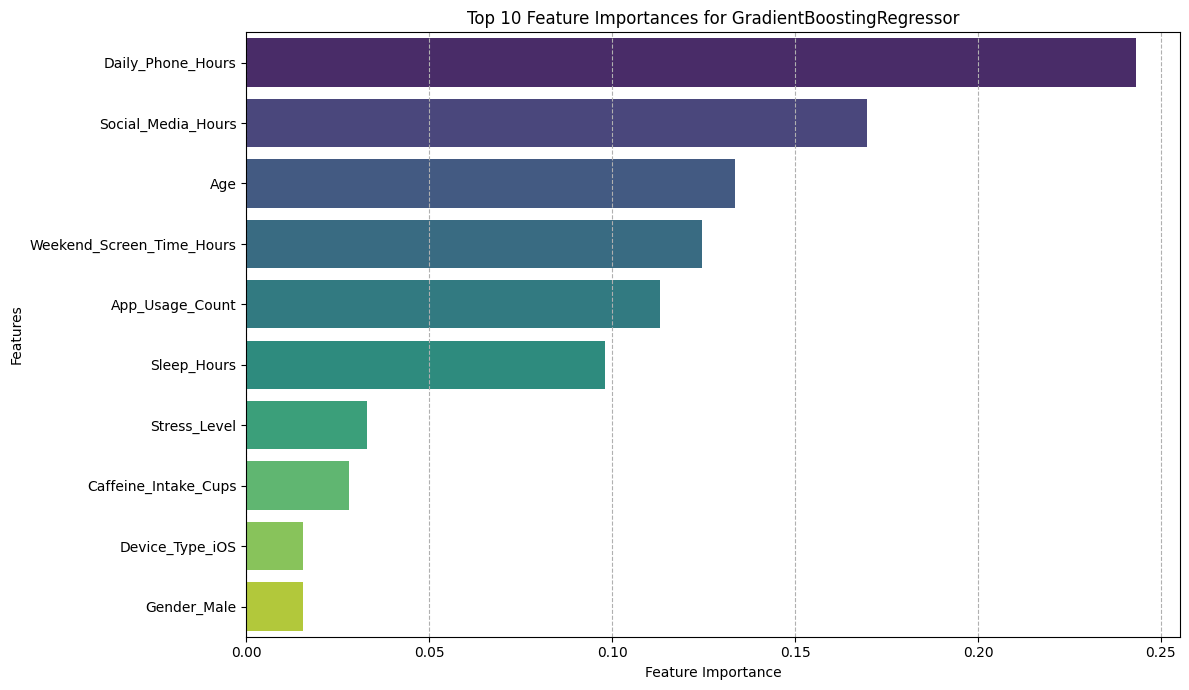

In [32]:
model_to_visualize = 'GradientBoostingRegressor'
importances = tree_model_importances[model_to_visualize]

# Select top 10 features for visualization
top_n = 10
top_importances = importances.head(top_n)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, palette='viridis', hue=top_importances.index, legend=False)
plt.title(f'Top {top_n} Feature Importances for {model_to_visualize}')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

## Summary of Feature Importances and Model Insights

### Coefficients from Linear Models (Linear Regression, Ridge, Lasso):
*   **Linear Regression and Ridge:** Both models show very small coefficients, suggesting that individual features have a minimal linear impact on the `Work_Productivity_Score`. The signs of the coefficients indicate direction: for example, 'Sleep_Hours' has a small positive coefficient, while 'Daily_Phone_Hours' and 'Weekend_Screen_Time_Hours' have small negative coefficients.
*   **Lasso:** The Lasso model, due to its L1 regularization, has driven all coefficients to exactly zero. This implies that none of the features, as they are currently, are strongly enough correlated to `Work_Productivity_Score` to be kept by the Lasso regularization. This also corroborates the very low R-squared scores observed earlier.

### Feature Importances from Tree-based Models (RandomForestRegressor, GradientBoostingRegressor):
*   **Both models identify a similar set of top features:** 'Daily_Phone_Hours', 'Social_Media_Hours', 'Age', 'Weekend_Screen_Time_Hours', 'App_Usage_Count', and 'Sleep_Hours' consistently appear as the most important features. These features collectively contribute a significant portion of the predictive power in these models.
*   **Relative Importance:** 'Daily_Phone_Hours' is consistently the most important feature, especially in the `GradientBoostingRegressor`, followed by 'Social_Media_Hours' and 'Age'. This indicates that the amount of time spent on the phone daily and on social media, along with the user's age, are the most influential factors in determining the `Work_Productivity_Score` according to these models.
*   **Categorical Features:** One-hot encoded categorical features (Gender, Occupation, Device_Type) show much lower importance compared to the numerical features, suggesting they have less direct influence on productivity score in these tree-based models.

### Overall Insights:
*   The very low (and even negative) R-squared values across all models indicate that none of the models, in their current form, are effectively explaining the variance in 'Work_Productivity_Score'. This is a critical finding, suggesting that the relationship between the features and the target variable is either very weak, highly non-linear, or that crucial predictive features are missing from the dataset.
*   While linear models assign very small or zero coefficients, tree-based models at least identify a hierarchical order of feature importance, highlighting screen time metrics (`Daily_Phone_Hours`, `Social_Media_Hours`, `Weekend_Screen_Time_Hours`) and `Age` as consistently influential.
*   The discrepancy between the linear models (zero/near-zero coefficients for Lasso/Ridge) and tree-based models (non-zero feature importances) suggests that if there is a relationship, it is likely complex and non-linear, which tree-based models are better equipped to capture than linear models. However, even these models struggled to achieve a positive R-squared score.

### Next Steps:
*   **Feature Engineering**: Explore creating new features or transforming existing ones. For instance, interaction terms between screen time and stress, or polynomial features for age, might reveal hidden relationships.
*   **Model Selection**: Consider more advanced non-linear models beyond tree ensembles, such as neural networks, which can learn complex patterns.
*   **Data Quality/Collection**: Re-evaluate the `Work_Productivity_Score` itself. Is it a reliable metric? Are there other unmeasured factors that strongly influence productivity?
*   **Domain Expertise**: Consult with domain experts to understand what other factors might affect work productivity and if relevant data can be collected.

# Smartphone Usage and Work Productivity Analysis

## Project Overview
This project aims to analyze the

This project aims to predict the `Work_Productivity_Score` based on smartphone usage and other related factors. We investigate various regression models to determine their effectiveness and identify the most influential predictors of productivity.

## Data Source
The dataset used for this analysis is the "Smartphone usage productivity dataset", extracted from Kaggle.

## Problem Statement
Can different variables reliably predict the productivity of people? What are the most influential predictors of productivity based on the collected data?

## Methodology

### 1. Data Import & Initial Exploration
- The dataset was loaded from a CSV file.
- Initial checks were performed to understand data structure (`df.info()`), identify missing values (`df.isnull().sum()`), and get descriptive statistics for numerical columns (`df.describe()`).
- Value counts for categorical columns (`Gender`, `Occupation`, `Device_Type`) were also examined.

### 2. Data Preprocessing
- **Feature Identification**: Categorical features (`Gender`, `Occupation`, `Device_Type`) and numerical features were identified.
- **One-Hot Encoding**: Categorical features were transformed into numerical format using one-hot encoding (`pd.get_dummies`) to prepare them for model training. The original categorical columns were dropped.

### 3. Model Training & Evaluation
- **Data Splitting**: The preprocessed dataset was divided into training (80%) and testing (20%) sets, with `Work_Productivity_Score` as the target variable.
- **Regression Models**: The following regression models were trained and evaluated:
    - Linear Regression
    - Ridge Regression
    - Lasso Regression
    - RandomForestRegressor
    - GradientBoostingRegressor
- **Evaluation Metrics**: Models were evaluated using Mean Squared Error (MSE) and R-squared ($R^2$) on the test set.

### 4. Model Predictions Visualization
- A scatter plot comparing actual vs. predicted `Work_Productivity_Score` values from the best-performing model (Lasso) was generated to visually assess its performance.

### 5. Feature Importance Analysis
- **Linear Models (Coefficients)**: Coefficients were extracted from Linear Regression, Ridge, and Lasso models to understand the linear impact of each feature.
- **Tree-based Models (Feature Importances)**: Feature importance scores were extracted from RandomForestRegressor and GradientBoostingRegressor models to identify non-linear relationships.

## Key Findings

### Model Performance
All models, including the best-performing Lasso model, showed very low or negative R-squared values (close to -0.0000 to -0.0295), indicating that none of the models were effectively explaining the variance in `Work_Productivity_Score` with the current features. The MSE values were consistently around 8.3-8.5.

### Feature Importance
- **Linear Models**: Coefficients for Linear Regression and Ridge were very small, suggesting minimal linear impact. Lasso drove all coefficients to zero, implying no strong linear correlation with the target variable after regularization.
- **Tree-based Models**: These models identified a consistent set of top influential features:
    - `Daily_Phone_Hours` (most important)
    - `Social_Media_Hours`
    - `Age`
    - `Weekend_Screen_Time_Hours`
    - `App_Usage_Count`
    - `Sleep_Hours`
- Categorical features (Gender, Occupation, Device_Type) showed much lower importance compared to numerical features in tree-based models.

## Conclusion & Next Steps

The overall low R-squared values suggest that the current features are insufficient to predict `Work_Productivity_Score` effectively, or the relationship is highly non-linear and not captured by these models.

To improve predictive performance, the following steps are recommended:
- **Feature Engineering**: Explore creating new features or transforming existing ones (e.g., interaction terms, polynomial features) to uncover hidden relationships.
- **Advanced Models**: Consider more complex non-linear models like neural networks.
- **Data Quality/Collection**: Re-evaluate the `Work_Productivity_Score` metric's reliability and consider gathering additional, potentially more relevant, data.
- **Domain Expertise**: Consult domain experts to understand other factors that might influence work productivity.

